# pyfantastat — Feature Demo

This notebook walks through every public API surface of **pyfantastat**, a Python library for Italian fantasy football (Fantacalcio) league analysis.

**Sections**
1. Loading a calendar from Excel
2. Building a Championship
3. Generating and displaying the ranking
4. Match result deep-dive
5. Analytics (W/D/L, SoS, scoring days, close matches, prizes)
6. Statistics module
7. What-if calendar analysis
8. Monte Carlo ranking simulation

## Setup

Install optional visualisation libraries if needed:

In [1]:
# Uncomment to install:
# import subprocess, sys
# subprocess.run([sys.executable, '-m', 'pip', 'install', 'matplotlib', 'pandas', 'seaborn'], check=True)

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 4)

---
## 1 · Loading a Calendar

Fantacalcio leagues are typically exported as Excel workbooks. `load_calendar_xlsx` parses the standard layout and returns a `CalendarData` dataclass.

The notebook first tries to load a real league file; if it's not found a synthetic eight-team dataset is used so every section still runs.

In [2]:
from pyfantastat import load_calendar_xlsx, CalendarData

XLSX_PATH = Path('..') / 'Calendario_FanTeo-Colleoni-di-Zona-1-2.xlsx'

try:
    data: CalendarData = load_calendar_xlsx(XLSX_PATH)
    print(f'Loaded: {XLSX_PATH.name}')
except FileNotFoundError:
    print('Real file not found — using synthetic data.')
    import random, collections
    rng = random.Random(0)
    _names = [f'Team{i}' for i in range(8)]
    _pts   = {n: [round(rng.uniform(55, 100), 1) for _ in range(23)] for n in _names}
    _cal   = []
    for rnd in range(7):
        shuffled = list(range(8)); rng.shuffle(shuffled)
        _cal.append([[shuffled[i], shuffled[i+1]] for i in range(0, 8, 2)])
    data = CalendarData(
        league_name='Synthetic League',
        team_names=_names, user_names=_names,
        team_points=_pts, match_count=23,
        calendar=_cal, current_matchday=23,
        first_matchday_serie_a=1, last_matchday_serie_a=23,
    )

print(f'League  : {data.league_name or "(unnamed)"}')
print(f'Teams   : {len(data.team_names)}')
print(f'Matchdays played : {data.current_matchday} / {data.match_count}')

Real file not found — using synthetic data.
League  : Synthetic League
Teams   : 8
Matchdays played : 23 / 23


In [3]:
# Fantapoints per team per matchday
played = data.current_matchday or data.match_count
df_pts = pd.DataFrame(
    {name: pts[:played] for name, pts in data.team_points.items()},
    index=pd.RangeIndex(1, played + 1, name='Matchday'),
).T
df_pts.columns.name = 'Matchday'
df_pts.style.background_gradient(cmap='RdYlGn', axis=1).format('{:.1f}')

Matchday,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
Team0,93.0,89.1,73.9,66.7,78.0,73.2,90.3,68.6,76.4,81.3,95.9,77.7,67.7,89.0,82.8,66.3,95.9,99.2,91.5,95.6,69.0,87.8,95.4
Team1,85.8,76.2,59.5,74.5,82.5,96.1,98.5,76.5,93.9,66.7,91.2,79.7,55.6,87.4,72.9,92.1,85.1,55.1,77.2,94.0,66.0,69.6,94.2
Team2,63.6,80.5,65.7,98.5,91.1,75.2,58.6,69.4,77.9,97.0,59.9,79.8,86.8,79.6,91.7,79.3,98.4,82.1,81.4,75.0,81.8,72.3,80.9
Team3,68.1,63.5,63.4,82.6,84.5,76.4,59.0,89.1,94.5,96.6,92.9,95.4,96.5,79.3,72.6,86.7,67.4,91.5,93.2,95.3,81.5,97.7,81.1
Team4,75.3,84.7,99.8,96.3,90.7,58.7,82.6,76.9,83.4,93.0,65.9,87.9,60.3,64.9,90.8,70.0,91.7,59.5,61.6,86.4,57.0,80.8,96.0
Team5,79.0,85.6,56.2,83.6,82.3,80.9,72.6,71.7,99.1,56.6,56.0,98.2,63.3,60.6,64.5,91.0,97.2,56.0,74.2,59.6,66.7,64.9,84.1
Team6,70.8,63.1,77.7,56.8,59.5,99.5,64.0,71.1,87.9,92.7,96.3,62.6,85.3,98.5,57.6,85.4,93.0,70.4,66.3,81.9,74.9,62.9,76.2
Team7,73.4,80.6,77.9,69.0,71.1,92.7,66.3,80.2,55.6,88.4,70.1,57.1,67.6,65.8,97.9,70.9,68.0,71.2,97.6,83.5,82.9,87.2,72.5


---
## 2 · Building a Championship

`Championship.from_calendar_data()` is the one-liner factory — it builds `Team` objects, populates their score histories, and attaches the calendar in a single call.

**Tiebreaker criteria (`card_order`)** are applied in order when two or more teams finish on equal league points. Available options:
- `"Punti"` — league points (always effective as a baseline)
- `"Somma punti totale"` — total fantapoints scored across the season
- `"Classifica avulsa"` — head-to-head points between tied teams
- `"Differenza reti"` — goal difference
- `"Gol fatti"` / `"Gol subiti"` — goals scored / conceded

In [4]:
from pyfantastat import Championship

TIEBREAKERS = ['Punti', 'Classifica avulsa', 'Differenza reti', 'Somma punti totale']

ch = Championship.from_calendar_data(
    data,
    card_order=TIEBREAKERS,
)

print(f'Competition type : {ch.competition_type}')
print(f'Goal threshold   : {ch.goal_threshold or 5} pts  ')
print(f'Interval mode    : {ch.interval}')
print(f'Teams registered : {len(ch.teams)}')

Competition type : Standard
Goal threshold   : 5 pts  
Interval mode    : False
Teams registered : 8


> **Manual construction** (alternative to the factory):
> ```python
> from pyfantastat import Team, Championship
> teams = []
> for name, user in zip(data.team_names, data.user_names):
>     t = Team(name, user)
>     t.add_fanta_pts_scored(data.team_points[name])
>     teams.append(t)
> ch = Championship(teams, card_order=TIEBREAKERS)
> ch.set_calendar(data.calendar)
> ```

---
## 3 · Generating and Displaying the Ranking

`generate_ranking()` replays every match in the calendar, converts fantapoints to goals using the configured thresholds, and awards 3/1/0 points per result. It is **idempotent** — safe to call multiple times.

In [5]:
ch.generate_ranking()
sorted_idx, warning = ch.sort_ranking()

if warning:
    print('⚠', warning)

rows = []
for rank, idx in enumerate(sorted_idx, start=1):
    t = ch.teams[idx]
    rows.append({
        'Rank': rank,
        'Team': t.team_name,
        'Manager': t.user_name,
        'Pts': int(ch.ranking[idx]),
        'G+': t.goals_scored,
        'G-': t.goals_conceded,
        'G±': t.goals_scored - t.goals_conceded,
        'Fpt': round(sum(t.fanta_pts_scored), 1),
    })

df_rank = pd.DataFrame(rows).set_index('Rank')
df_rank

,Team,Manager,Pts,G+,G-,G±,Fpt
Rank,,,,,,,
1,Team4,Team4,18,29.0,10.0,19.0,1814.2
2,Team0,Team0,16,24.0,16.0,8.0,1904.3
3,Team7,Team7,13,18.0,10.0,8.0,1747.5
4,Team1,Team1,10,27.0,25.0,2.0,1830.3
5,Team5,Team5,9,20.0,30.0,-10.0,1703.9
6,Team2,Team2,7,18.0,21.0,-3.0,1826.5
7,Team6,Team6,5,11.0,18.0,-7.0,1754.4
8,Team3,Team3,3,12.0,29.0,-17.0,1908.8


---
## 4 · Match Result Deep-Dive

Goals are awarded by counting how many thresholds a team's fantapoints cross. With the default 5-point gap the thresholds are 66, 71, 76, 81, 86, 91, 96.

- **Result code 1** → team A wins
- **Result code 2** → team B wins
- **Result code 0** → draw

In [6]:
# Single match from the calendar
match = ch.calendar[0][0]
result, goals = ch.match_result(match, matchday=0)
ta, tb = ch.teams[match[0]].team_name, ch.teams[match[1]].team_name
label = {1: f'{ta} wins', 2: f'{tb} wins', 0: 'Draw'}[result]
print(f'Match: {ta} vs {tb}')
print(f'Fantapoints: {ch.teams[match[0]].fanta_pts_scored[0]:.1f}  vs  {ch.teams[match[1]].fanta_pts_scored[0]:.1f}')
print(f'Goals: {int(goals[0])}  -  {int(goals[1])}')
print(f'Result: {label} (code {result})')

Match: Team1 vs Team3
Fantapoints: 85.8  vs  68.1
Goals: 4  -  1
Result: Team1 wins (code 1)


In [7]:
# Standalone calculation without a calendar
result2, goals2 = ch.match_result_from_points(78.5, 72.0)
print(f'78.5 vs 72.0 → goals {int(goals2[0])}-{int(goals2[1])}, result code {result2}')

78.5 vs 72.0 → goals 3-2, result code 1


In [8]:
# Full results grid for all played matchdays
rows_res = []
for day_idx, day in enumerate(ch.calendar):
    for match in day:
        res, g = ch.match_result(match, day_idx)
        ta_name = ch.teams[match[0]].team_name
        tb_name = ch.teams[match[1]].team_name
        pts_a = ch.teams[match[0]].fanta_pts_scored[day_idx]
        pts_b = ch.teams[match[1]].fanta_pts_scored[day_idx]
        outcome = {1: 'W/L', 2: 'L/W', 0: 'D/D'}[res]
        rows_res.append({
            'Round': day_idx + 1,
            'Home': ta_name,
            'Fpt H': pts_a,
            'Fpt A': pts_b,
            'Away': tb_name,
            'Goals': f'{int(g[0])}-{int(g[1])}',
            'Result': outcome,
        })

pd.DataFrame(rows_res)

,Round,Home,Fpt H,Fpt A,Away,Goals,Result
0,1,Team1,85.8,68.1,Team3,4-1,W/L
1,1,Team2,63.6,75.3,Team4,0-2,L/W
2,1,Team0,93.0,79.0,Team5,6-3,W/L
3,1,Team7,73.4,70.8,Team6,2-1,W/L
4,2,Team0,89.1,80.5,Team2,5-3,W/L
5,2,Team4,84.7,63.5,Team3,4-0,W/L
6,2,Team7,80.6,63.1,Team6,3-0,W/L
7,2,Team1,76.2,85.6,Team5,3-4,L/W
8,3,Team1,59.5,77.9,Team7,0-3,L/W
9,3,Team2,65.7,77.7,Team6,0-3,L/W


---
## 5 · Analytics

All analytics methods require `generate_ranking()` to have been called first (it populates `goals_scored` / `goals_conceded` on each team).

### 5.1 Wins, Draws & Losses

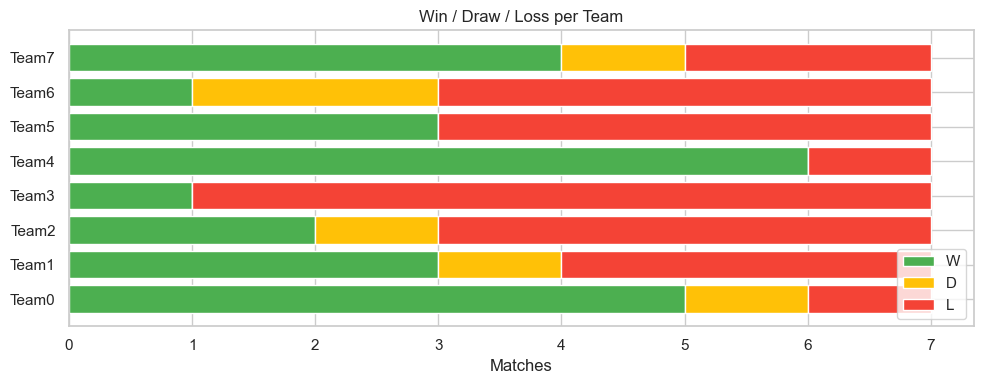

,W,D,L
Team0,5,1,1
Team1,3,1,3
Team2,2,1,4
Team3,1,0,6
Team4,6,0,1
Team5,3,0,4
Team6,1,2,4
Team7,4,1,2


In [9]:
wdl = ch.get_wins_draws_losses()
df_wdl = pd.DataFrame(wdl).T[['W', 'D', 'L']]

fig, ax = plt.subplots(figsize=(10, 4))
left = np.zeros(len(df_wdl))
colours = {'W': '#4CAF50', 'D': '#FFC107', 'L': '#F44336'}
for col in ['W', 'D', 'L']:
    ax.barh(df_wdl.index, df_wdl[col], left=left, label=col, color=colours[col])
    left += df_wdl[col].values
ax.set_xlabel('Matches')
ax.set_title('Win / Draw / Loss per Team')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()
df_wdl

### 5.2 Strength of Schedule

Average fantapoints scored by each team's opponents — a high value means facing tougher competition.

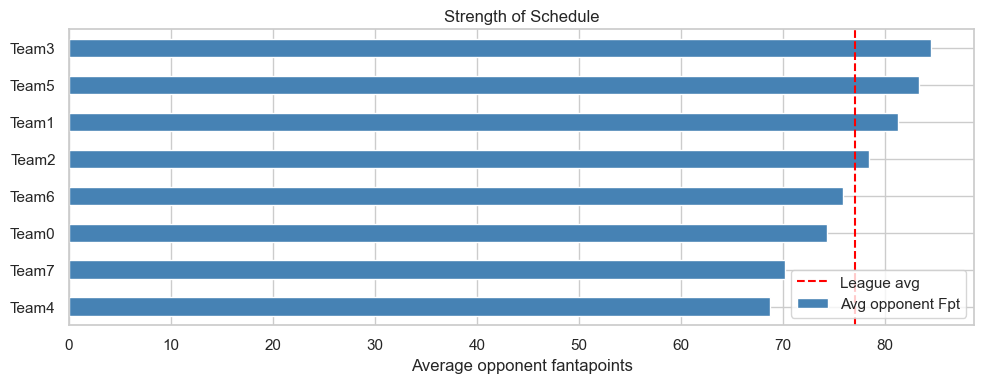

In [10]:
sos = {ch.teams[i].team_name: ch.strength_of_schedule(i) for i in range(len(ch.teams))}
df_sos = pd.Series(sos, name='Avg opponent Fpt').sort_values()

fig, ax = plt.subplots(figsize=(10, 4))
df_sos.plot.barh(ax=ax, color='steelblue')
ax.set_xlabel('Average opponent fantapoints')
ax.set_title('Strength of Schedule')
ax.axvline(df_sos.mean(), color='red', linestyle='--', label='League avg')
ax.legend()
plt.tight_layout()
plt.show()

### 5.3 Total Fantapoints Ranking

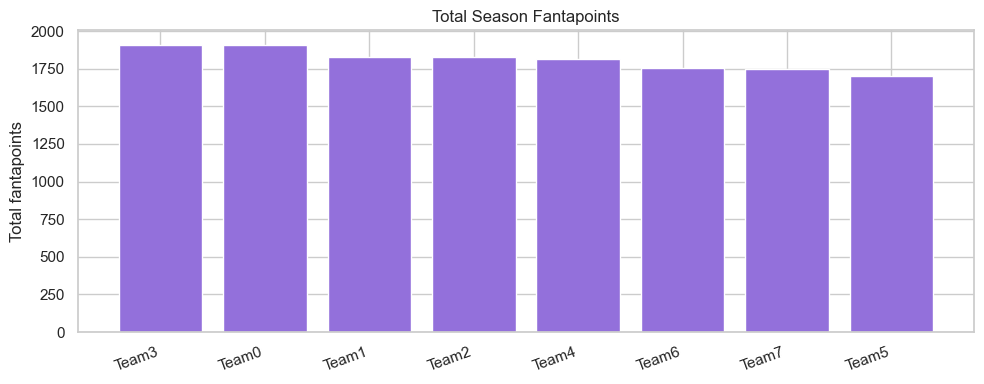

In [11]:
fpt_rank = ch.total_fpt_ranking()
names_fpt, totals = zip(*fpt_rank)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(names_fpt, totals, color='mediumpurple')
ax.set_ylabel('Total fantapoints')
ax.set_title('Total Season Fantapoints')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

### 5.4 Highest & Lowest Scoring Matchdays

Combined fantapoints across all matches played on each round.

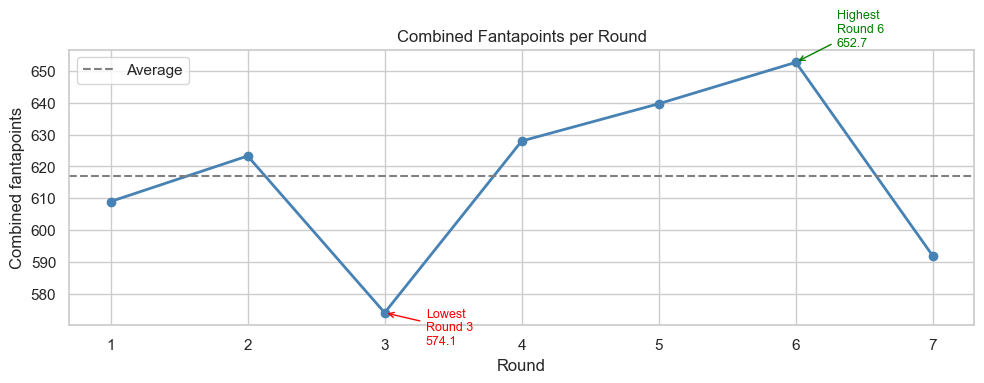

In [12]:
lo_day, lo_score = ch.lowest_scoring_day()
hi_day, hi_score = ch.highest_scoring_day()

# Build per-round combined scores
day_scores = []
for day_idx, day in enumerate(ch.calendar):
    total = sum(
        ch.teams[m[0]].fanta_pts_scored[day_idx] + ch.teams[m[1]].fanta_pts_scored[day_idx]
        for m in day
    )
    day_scores.append(total)

fig, ax = plt.subplots(figsize=(10, 4))
x = range(1, len(day_scores) + 1)
ax.plot(x, day_scores, marker='o', color='steelblue', linewidth=2)
ax.axhline(np.mean(day_scores), color='grey', linestyle='--', label='Average')
ax.annotate(f'Highest\nRound {hi_day+1}\n{hi_score:.1f}',
            xy=(hi_day+1, hi_score), xytext=(hi_day+1.3, hi_score+5),
            arrowprops=dict(arrowstyle='->', color='green'), color='green', fontsize=9)
ax.annotate(f'Lowest\nRound {lo_day+1}\n{lo_score:.1f}',
            xy=(lo_day+1, lo_score), xytext=(lo_day+1.3, lo_score-10),
            arrowprops=dict(arrowstyle='->', color='red'), color='red', fontsize=9)
ax.set_xlabel('Round')
ax.set_ylabel('Combined fantapoints')
ax.set_title('Combined Fantapoints per Round')
ax.legend()
plt.tight_layout()
plt.show()

### 5.5 Close Matches & Close Draws

A match is **close** when both teams score ≥ 66 fantapoints and the difference between them is ≤ 3 points. A **close draw** is a close match that also ends level on goals.

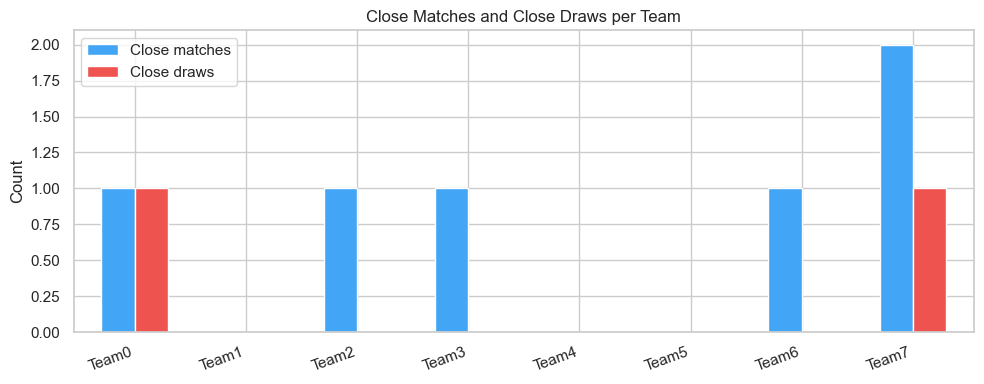

In [13]:
close = ch.number_close_matches()
draws = ch.close_draws()

df_close = pd.DataFrame({'Close matches': close, 'Close draws': draws})

fig, ax = plt.subplots(figsize=(10, 4))
df_close.plot.bar(ax=ax, color=['#42A5F5', '#EF5350'], width=0.6)
ax.set_ylabel('Count')
ax.set_title('Close Matches and Close Draws per Team')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

### 5.6 Prizes

Best and worst individual performances across all matchdays.

In [14]:
p = ch.prizes()
hi, lo = p['highest'], p['lowest']
print('🏆  Best performance')
print(f'   Team     : {hi["team_name"]}')
print(f'   Matchday : Round {hi["matchday"] + 1}')
print(f'   Points   : {hi["points"]}')
print()
print('😬  Worst performance')
print(f'   Team     : {lo["team_name"]}')
print(f'   Matchday : Round {lo["matchday"] + 1}')
print(f'   Points   : {lo["points"]}')

🏆  Best performance
   Team     : Team4
   Matchday : Round 3
   Points   : 99.8

😬  Worst performance
   Team     : Team5
   Matchday : Round 3
   Points   : 56.2


---
## 6 · Statistics Module

Pure numeric utilities (`mean`, `std`, `median`, `pearson_correlation`) plus domain-aware helpers that work directly on `Team` objects.

In [15]:
from pyfantastat import mean, std, median, pearson_correlation
from pyfantastat.statistics import team_scoring_stats, scoring_correlation

# Pick a reference team
ref = ch.teams[0]
print(f'Team: {ref.team_name}')
print(f'  mean   : {mean(ref.fanta_pts_scored):.2f}')
print(f'  std    : {std(ref.fanta_pts_scored):.2f}')
print(f'  median : {median(ref.fanta_pts_scored):.2f}')

Team: Team0
  mean   : 82.80
  std    : 10.81
  median : 82.80


In [16]:
# team_scoring_stats — all three in one call
rows_stats = []
for t in ch.teams:
    s = team_scoring_stats(t)
    rows_stats.append({'Team': t.team_name, **{k: round(v, 2) for k, v in s.items()}})

pd.DataFrame(rows_stats).set_index('Team')

,mean,std,median
Team,,,
Team0,82.80,10.81,82.8
Team1,79.58,12.88,79.7
Team2,79.41,11.11,79.8
Team3,82.99,12.02,84.5
Team4,78.88,13.60,82.6
Team5,74.08,14.01,72.6
Team6,76.28,13.53,74.9
Team7,75.98,11.29,72.5


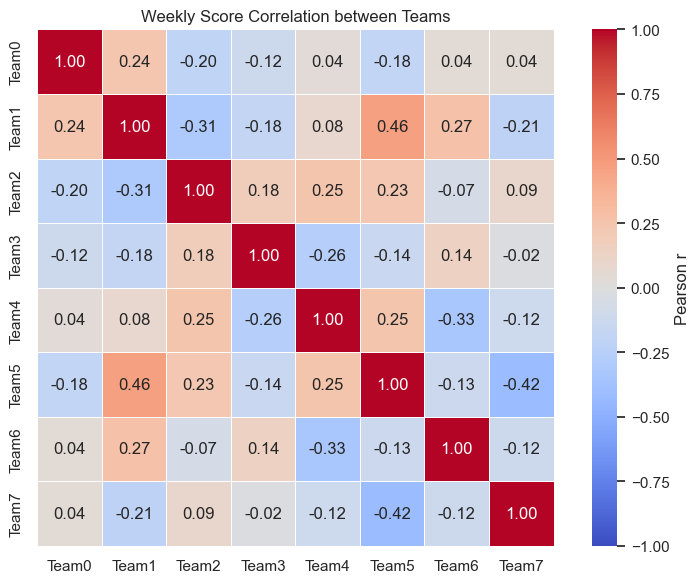

In [17]:
# Pairwise Pearson correlation matrix
names = [t.team_name for t in ch.teams]
n = len(ch.teams)
corr_mat = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        if i == j:
            corr_mat[i, j] = 1.0
        elif i < j:
            c = scoring_correlation(ch.teams[i], ch.teams[j])
            corr_mat[i, j] = corr_mat[j, i] = c

df_corr = pd.DataFrame(corr_mat, index=names, columns=names)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df_corr, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, ax=ax, square=True,
            linewidths=0.5, cbar_kws={'label': 'Pearson r'})
ax.set_title('Weekly Score Correlation between Teams')
plt.tight_layout()
plt.show()

---
## 7 · What-If Calendar Analysis

`what_if_calendar(team_a_idx, team_b_idx)` asks: *how many league points would team A have accumulated if it had played team B's opponents instead of its own?*

It re-runs every matchday using team A's actual fantapoints against whichever team B faced that day.

In [18]:
# Single pair example
a_idx, b_idx = sorted_idx[0], sorted_idx[-1]  # 1st vs last place
actual, what_if = ch.what_if_calendar(a_idx, b_idx)
ta_name, tb_name = ch.teams[a_idx].team_name, ch.teams[b_idx].team_name
print(f'{ta_name} actual points       : {actual}')
print(f'{ta_name} on {tb_name}⁻¹ schedule : {what_if}')
delta = what_if - actual
sign = '+' if delta >= 0 else ''
print(f'Difference                    : {sign}{delta} pts')

Team4 actual points       : 18
Team4 on Team3⁻¹ schedule : 6
Difference                    : -12 pts


In [19]:
# Full what-if matrix
n = len(ch.teams)
wi_mat = np.zeros((n, n), dtype=int)
for i in range(n):
    for j in range(n):
        if i != j:
            _, wi = ch.what_if_calendar(i, j)
            wi_mat[i, j] = wi
        else:
            wi_mat[i, j] = int(ch.ranking[i])

names = [t.team_name for t in ch.teams]
df_wi = pd.DataFrame(wi_mat, index=names, columns=names)
df_wi.index.name = 'Team A'
df_wi.columns.name = "On Team B's schedule"
df_wi.style.background_gradient(cmap='RdYlGn', axis=None)

On Team B's schedule,Team0,Team1,Team2,Team3,Team4,Team5,Team6,Team7
Team A,,,,,,,,
Team0,16,10,7,11,13,10,12,14
Team1,15,10,10,7,14,10,11,19
Team2,11,6,7,3,13,5,9,10
Team3,10,4,4,3,11,3,6,10
Team4,13,11,13,6,18,11,16,18
Team5,14,7,9,4,15,9,14,15
Team6,6,4,5,6,11,4,5,8
Team7,9,7,8,6,15,6,8,13


---
## 8 · Monte Carlo Ranking Simulation

`MonteCarloSimulator` estimates the probability that each team finishes in each position by simulating thousands of seasons. Each simulated season randomly draws a calendar from a pre-computed pool (included in the package for 8, 10, or 12 teams) and replays matches using the teams' actual historical fantapoints.

The simulation stops early when the rank-probability matrix stabilises (`patience` consecutive checkpoints with max change < `tol`).

In [20]:
from pyfantastat.monte_carlo import MonteCarloSimulator

sim = MonteCarloSimulator(
    ch,
    n_iterations=50_000,
    batch=10_000,
    patience=3,
    tol=0.01,
    seed=42,
)
result = sim.run()

print(f'Seasons simulated : {result.iterations_run:,}')
print(f'Converged early   : {result.converged}')

Seasons simulated : 40,000
Converged early   : True


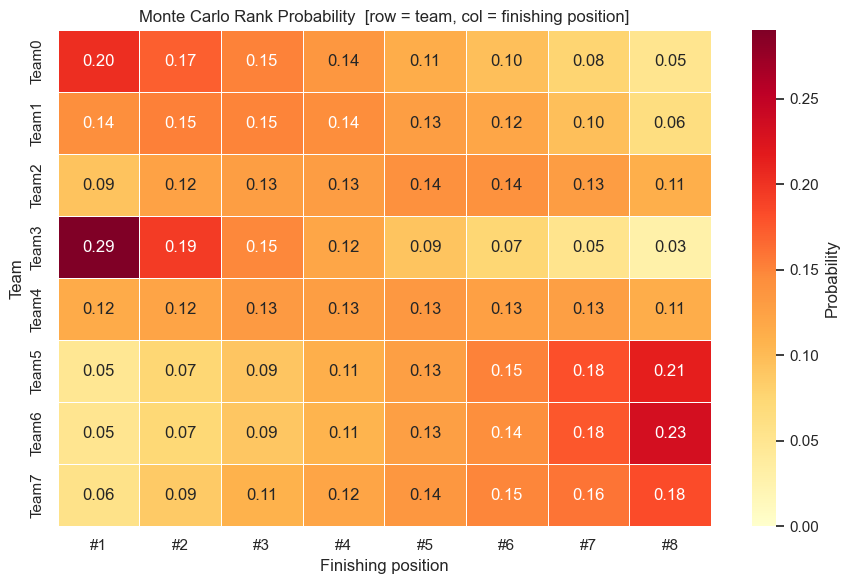

In [21]:
# Rank probability heatmap
names = [t.team_name for t in ch.teams]
rank_labels = [f'#{r}' for r in range(1, len(names) + 1)]

df_rp = pd.DataFrame(
    result.rank_probabilities,
    index=names,
    columns=rank_labels,
)

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(
    df_rp, annot=True, fmt='.2f', cmap='YlOrRd',
    vmin=0, vmax=df_rp.values.max(), ax=ax, linewidths=0.5,
    cbar_kws={'label': 'Probability'},
)
ax.set_title('Monte Carlo Rank Probability  [row = team, col = finishing position]')
ax.set_xlabel('Finishing position')
ax.set_ylabel('Team')
plt.tight_layout()
plt.show()

In [22]:
# Expected league points per team
df_ep = pd.DataFrame({
    'Team': names,
    'Expected points': result.expected_points.round(2),
    'P(finish 1st)': result.rank_probabilities[:, 0].round(4),
}).sort_values('Expected points', ascending=False).reset_index(drop=True)
df_ep.index += 1
df_ep.index.name = 'MC Rank'
df_ep

,Team,Expected points,P(finish 1st)
MC Rank,,,
1,Team3,12.37,0.2900
2,Team0,11.35,0.2029
3,Team1,10.80,0.1431
4,Team4,10.06,0.1164
5,Team2,9.79,0.0940
6,Team7,9.00,0.0556
7,Team5,8.62,0.0477
8,Team6,8.35,0.0504


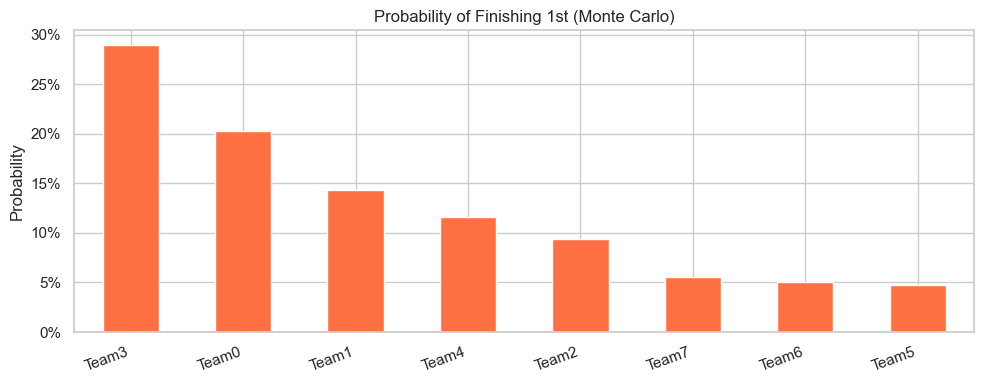

In [23]:
# P(finish 1st) bar chart
p1 = pd.Series(
    result.rank_probabilities[:, 0],
    index=names,
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
p1.plot.bar(ax=ax, color='#FF7043')
ax.set_ylabel('Probability')
ax.set_title('Probability of Finishing 1st (Monte Carlo)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()